In [1]:
import numpy as np
import pandas as pd
from numba import njit
from datetime import timedelta
import talib
import vectorbt as vbt
from vectorbt.indicators.factory import IndicatorFactory

from alpaca.data.historical import StockHistoricalDataClient
from alpaca.data.requests import StockBarsRequest
from alpaca.data.timeframe import TimeFrame, TimeFrameUnit

#My other files
from Data_Handling import *
from Alpaca_Credentials import ALPACA_API_KEY, ALPACA_SECRET_KEY
client = StockHistoricalDataClient(ALPACA_API_KEY, ALPACA_SECRET_KEY)


import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter
from itertools import product
import optuna
from sklearn.linear_model import LinearRegression
from scipy.stats import linregress, pearsonr


In [2]:
# Configuration
symbol = "AAPL"
start_date = "2023-01-01"
end_date = "2023-12-31"
timeframe_unit = "Hour"
multiplier = 4


entry_thresholds = np.arange(5,40,5)
exit_thresholds = np.arange (60,95,5)
rsi_periods = np.arange (7, 98, 7)

In [3]:
# 1. Load Data
data = get_data_auto(symbol, start=start_date, end=end_date, timeframe_unit=timeframe_unit, multiplier=multiplier)
# this gives 24h data not just trading hours so we need to take that into account

optimization_window = 90 # 45 days
execution_window = 30 # 15 days

In [4]:
#2. Define Strategy
@njit
def logic(rsi_vals, entry_threshold, exit_threshold):
    signals = np.where(rsi_vals<entry_threshold,1,0)
    return np.where(rsi_vals>exit_threshold,-1,signals)

def run_RSI_strat1(close, entry_threshold, exit_threshold, rsi_period):
    rsi_vals = vbt.IndicatorFactory.from_talib("RSI").run(close, rsi_period).real.to_numpy()
    return logic(rsi_vals, entry_threshold, exit_threshold)

RSI_strat1 = IndicatorFactory(
    class_name="RSI1",
    short_name="rsi1",
    input_names=["close"],
    param_names=["entry_threshold","exit_threshold","rsi_period"],
    output_names=["signals"] 
    ).from_apply_func(
        run_RSI_strat1
        )



In [5]:
#3. Walk-forward Loop
all_trades = []
all_pf=[]

dates = data.index.unique()
total_iterations = (len(dates) - optimization_window) // execution_window

for i in range(total_iterations):
    i = optimization_window + (i * execution_window)
    training_start = dates[i - optimization_window]
    training_end = dates[i - 1]
    test_start = dates[i]
    test_end = dates[i + execution_window]

    training_data = data.loc[training_start:training_end]
    test_data = data.loc[test_start:test_end]

    #3.1 Optimize on traning dates over parameters
    call_signals = RSI_strat1.run(
        close=training_data["Close"],
        entry_threshold=entry_thresholds,
        exit_threshold=exit_thresholds,
        rsi_period=rsi_periods,
        param_product=True
    )

    pf_test = vbt.Portfolio.from_signals(
        close=training_data["Close"],
        entries=(call_signals.signals == 1.0),
        exits=(call_signals.signals == -1.0),
        size=1,
        sl_stop=0.05,
        tp_stop= 0.1,
        freq="4h"
    )

    best_params, best_value, best_pf = Overfitting_reduction_simpler(
        pf_test, objective_function=None, smoothing_size=5, filter_threshold=0.0)

    #3.2 Run with optimised parameters
    optimum_signals = RSI_strat1.run(
        close=test_data["Close"],
        entry_threshold=best_params["rsi1_entry_threshold"],
        exit_threshold=best_params["rsi1_exit_threshold"],
        rsi_period=best_params["rsi1_rsi_period"]
    )

    pf_results = vbt.Portfolio.from_signals(
        close=test_data["Close"],
        entries=(optimum_signals.signals == 1.0),
        exits=(optimum_signals.signals == -1.0),
        size=1,
        sl_stop=0.05,
        tp_stop= 0.1,
        freq="4h"
    )

    #4 Record all trades
    trades_df = pf_results.trades.records[['entry_idx', 'exit_idx']].copy()

    offset = data.index.get_loc(test_data.index[0])
    trades_df['entry_idx'] += offset
    trades_df['exit_idx'] += offset
    all_trades.append(trades_df)

    #5 Record all pfs and deciision metrics
    all_pf.append({
        "Portfolios": pf_results,
        "Expected Returns": best_value,
        "params": best_params,
        "date": test_start
        })


In [6]:
all_trades_df = pd.concat(all_trades, ignore_index=True)
entries, exits = build_signals_from_trade_indices(all_trades_df, data.index)


final_pf = vbt.Portfolio.from_signals(
    close=data["Close"],
    entries=entries,
    exits=exits,
    size=1,
    sl_trail=0.01,
    freq="4h"
)

final_pf.plot()



FigureWidget({
    'data': [{'legendgroup': '0',
              'line': {'color': '#1f77b4'},
              'name': 'Close',
              'showlegend': True,
              'type': 'scatter',
              'uid': 'ed414da7-87de-4e8c-9cf9-88fe2acc3dc1',
              'x': array([datetime.datetime(2023, 1, 3, 8, 0, tzinfo=TzInfo(UTC)),
                          datetime.datetime(2023, 1, 3, 12, 0, tzinfo=TzInfo(UTC)),
                          datetime.datetime(2023, 1, 3, 16, 0, tzinfo=TzInfo(UTC)), ...,
                          datetime.datetime(2023, 12, 29, 16, 0, tzinfo=TzInfo(UTC)),
                          datetime.datetime(2023, 12, 29, 20, 0, tzinfo=TzInfo(UTC)),
                          datetime.datetime(2023, 12, 30, 0, 0, tzinfo=TzInfo(UTC))], dtype=object),
              'xaxis': 'x',
              'y': array([130.38  , 125.595 , 124.6283, ..., 192.47  , 192.1894, 192.1501]),
              'yaxis': 'y'},
             {'customdata': array([[ 0.        ,  0.65889218,  0.    

In [7]:
# Build signals
all_trades_df = pd.concat(all_trades, ignore_index=True)
entries, exits = build_signals_from_trade_indices(all_trades_df, data.index)

# Slice by date using .loc to preserve correct datetime index
trading_period_data = data["Close"].iloc[optimization_window:]
trading_period_entries = entries.iloc[optimization_window:]
trading_period_exits = exits.iloc[optimization_window:]

# Create final portfolio
final_pf = vbt.Portfolio.from_signals(
    close=trading_period_data,
    entries=trading_period_entries,
    exits=trading_period_exits,
    size=1,
    sl_trail=0.01,
    freq="4h"
)

# Plot with correct hover labels
final_pf.plot()


FigureWidget({
    'data': [{'legendgroup': '0',
              'line': {'color': '#1f77b4'},
              'name': 'Close',
              'showlegend': True,
              'type': 'scatter',
              'uid': 'e9bbe249-db33-4abd-9199-241fa6db45f4',
              'x': array([datetime.datetime(2023, 1, 31, 0, 0, tzinfo=TzInfo(UTC)),
                          datetime.datetime(2023, 1, 31, 8, 0, tzinfo=TzInfo(UTC)),
                          datetime.datetime(2023, 1, 31, 12, 0, tzinfo=TzInfo(UTC)), ...,
                          datetime.datetime(2023, 12, 29, 16, 0, tzinfo=TzInfo(UTC)),
                          datetime.datetime(2023, 12, 29, 20, 0, tzinfo=TzInfo(UTC)),
                          datetime.datetime(2023, 12, 30, 0, 0, tzinfo=TzInfo(UTC))], dtype=object),
              'xaxis': 'x',
              'y': array([143.    , 141.93  , 143.16  , ..., 192.47  , 192.1894, 192.1501]),
              'yaxis': 'y'},
             {'customdata': array([[ 0.        ,  0.65889218,  0.  

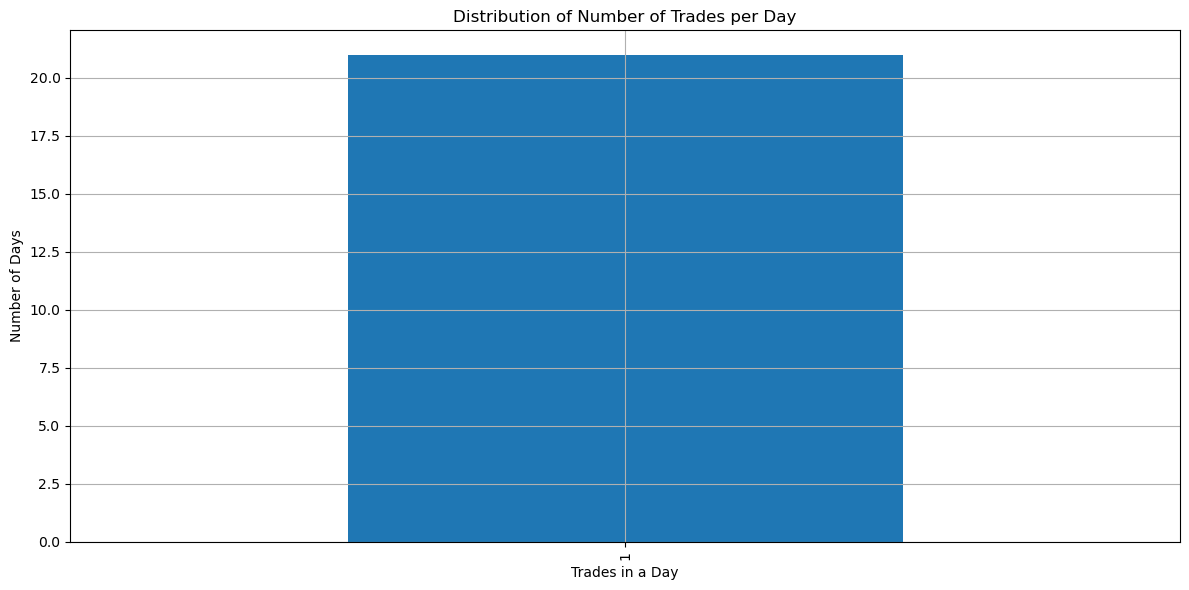

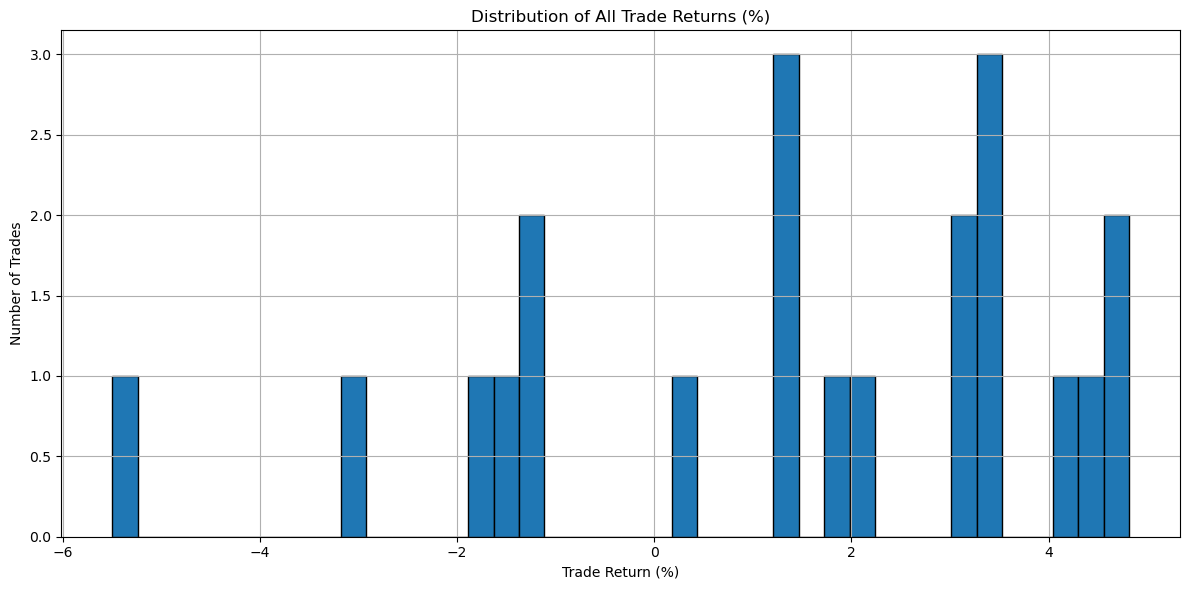

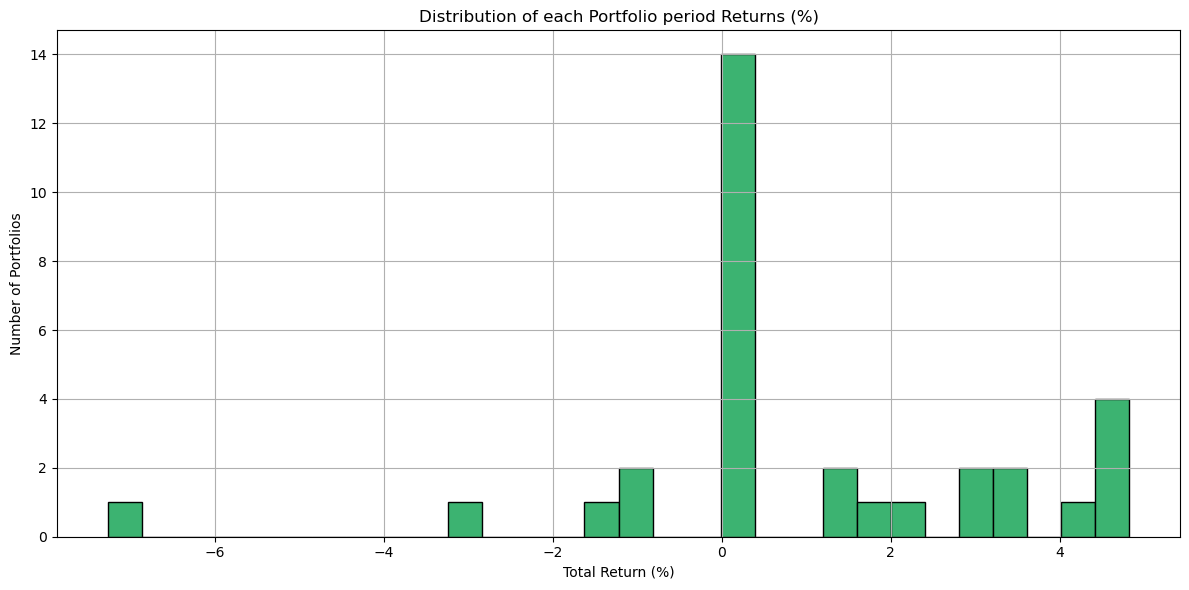

In [8]:

plot_trade_frequency_distribution_per_day(all_trades, data)
plot_trade_return_distribution_from_pf(final_pf)
plot_portfolios_return_distribution(all_pf)

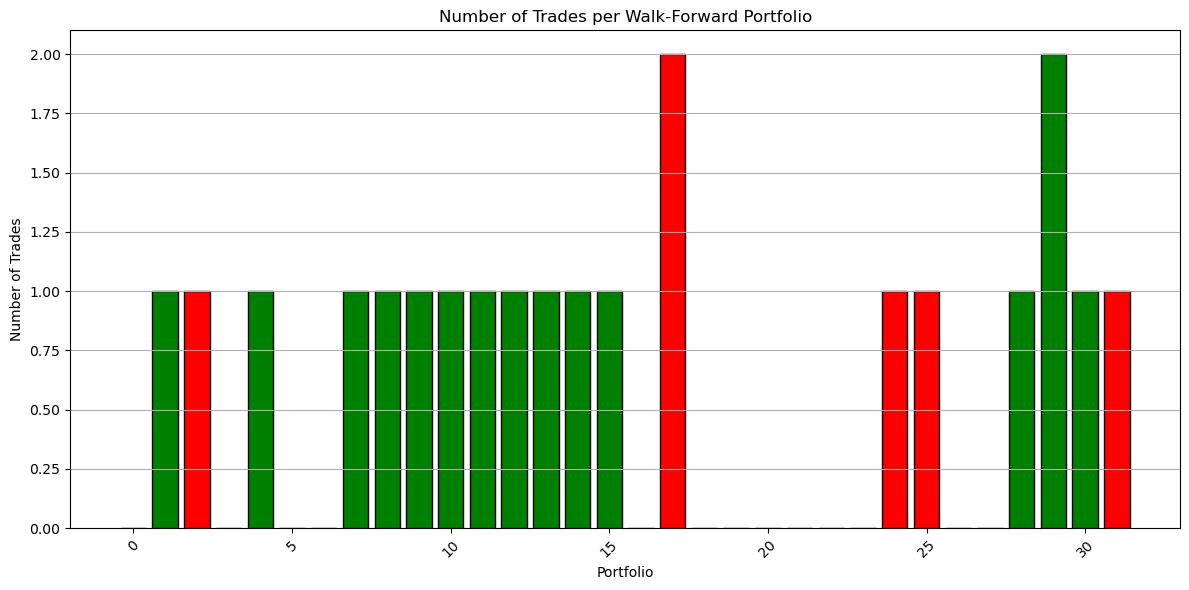

In [9]:
plot_trades_per_portfolio(all_trades,all_pf)


In [10]:
# Lets look at the dates of those very negative vals 
# Idea is if they are consecutive or show patterns we can look at how to reduce them
bad_indices = [i for i, entry in enumerate(all_pf) if entry["Portfolios"].total_return() <= -0.009]

for i in bad_indices:
    print(f"Index: {i}, Date: {all_pf[i]['date']}, Return: {all_pf[i]['Portfolios'].total_return():.2%}")


Index: 2, Date: 2023-02-16 12:00:00+00:00, Return: -2.94%
Index: 17, Date: 2023-07-26 20:00:00+00:00, Return: -7.26%
Index: 24, Date: 2023-10-10 12:00:00+00:00, Return: -1.47%
Index: 25, Date: 2023-10-19 20:00:00+00:00, Return: -1.15%
Index: 31, Date: 2023-12-14 12:00:00+00:00, Return: -1.16%


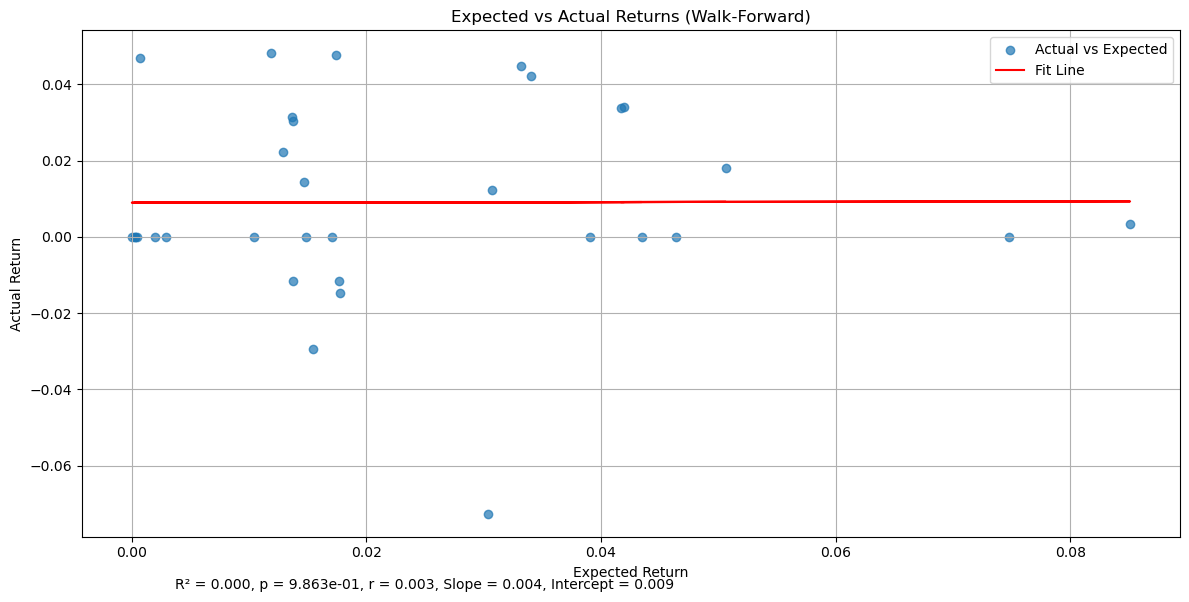

In [11]:
plot_expected_vs_actual_returns(all_pf)

Statistical Summary:

R² = 0.000: The model explains 0% of the variance in actual returns.

p = 0.986: Very high p-value, indicating the slope is not statistically significant — essentially, the expected returns are not predictive of actual returns.

r = 0.003: Correlation is close to zero.

Overall: This is essentially random scatter.

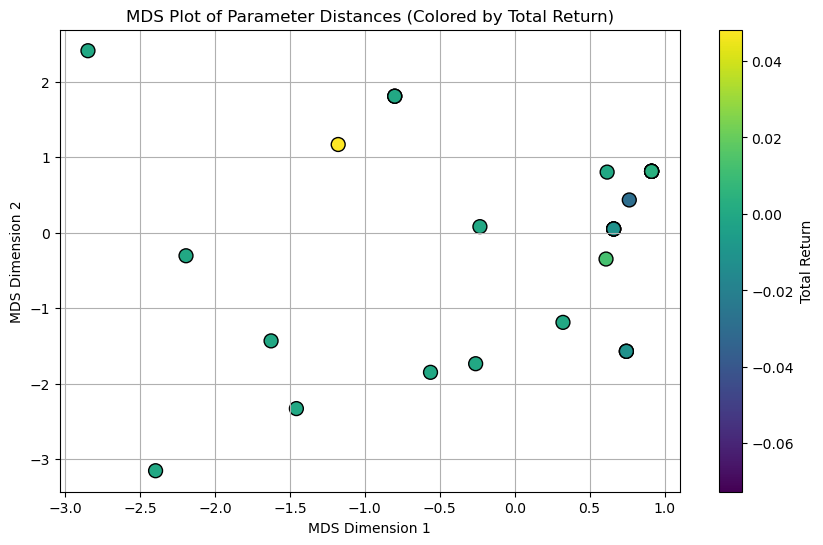

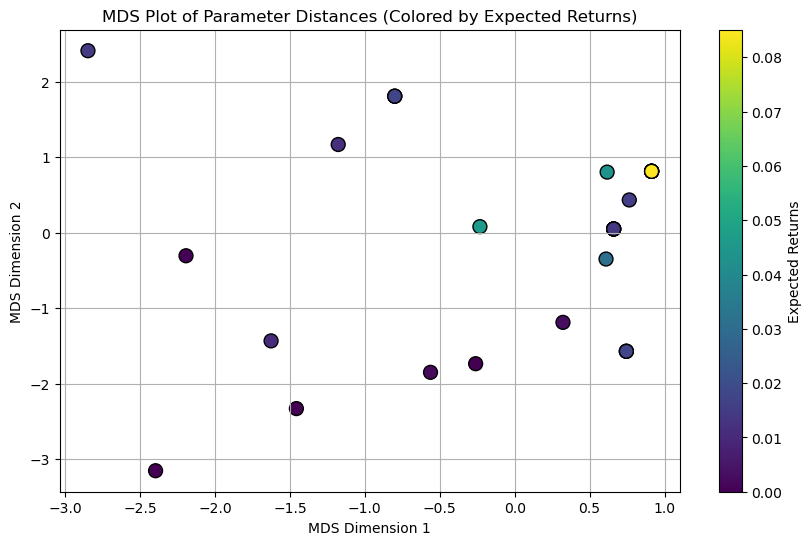

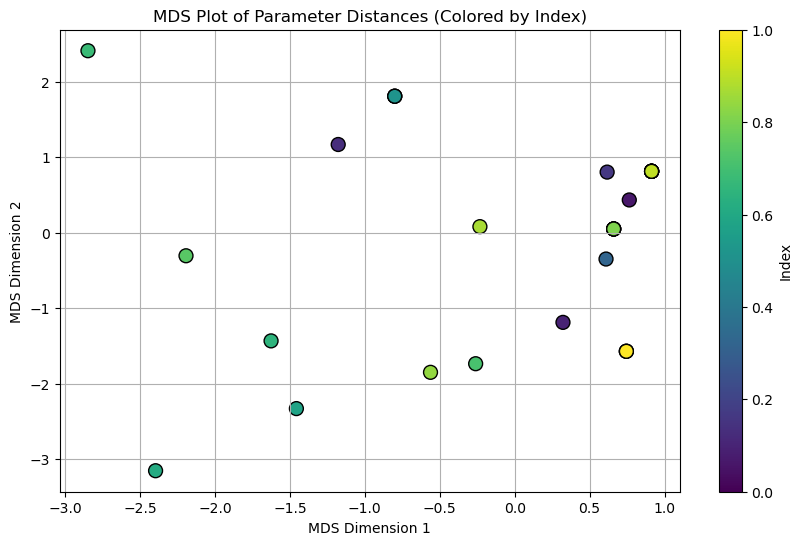

In [12]:
from sklearn.manifold import MDS
from sklearn.preprocessing import StandardScaler

def plot_parameter_mds(all_pf, color_by='Total Return'):
    # Extract parameter sets
    param_list = [entry['params'] for entry in all_pf]
    param_df = pd.DataFrame(param_list)

    # Get color values
    if color_by == 'Total Return':
        color_values = [entry['Portfolios'].total_return() for entry in all_pf]
    elif color_by == 'Expected Returns':
        color_values = [entry.get('Expected Returns', np.nan) for entry in all_pf]
    elif color_by == 'Index':
        color_values = np.linspace(0, 1, len(all_pf))
    elif color_by == 'Reverse_Index':
        color_values = np.linspace(1, 0, len(all_pf))
    else:
        raise ValueError(f"Unsupported color_by option: {color_by}")

    # Normalize parameters
    scaler = StandardScaler()
    param_scaled = scaler.fit_transform(param_df)

    # Perform MDS
    mds = MDS(n_components=2, dissimilarity='euclidean', random_state=42)
    mds_coords = mds.fit_transform(param_scaled)

    # Plot
    plt.figure(figsize=(10, 6))
    scatter = plt.scatter(
        mds_coords[:, 0],
        mds_coords[:, 1],
        c=color_values,
        cmap='viridis',
        s=100,
        edgecolor='k'
    )
    plt.colorbar(scatter, label=color_by)
    plt.title(f'MDS Plot of Parameter Distances (Colored by {color_by})')
    plt.xlabel('MDS Dimension 1')
    plt.ylabel('MDS Dimension 2')
    plt.grid(True)
    plt.show()



plot_parameter_mds(all_pf, color_by='Total Return')
plot_parameter_mds(all_pf, color_by='Expected Returns')
plot_parameter_mds(all_pf, color_by='Index')




In [13]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.cm import ScalarMappable
from matplotlib import cm
import numpy as np
from IPython.display import HTML
from matplotlib.collections import LineCollection

from sklearn.manifold import MDS
from sklearn.preprocessing import StandardScaler

# 1. Extract parameter vectors
param_list = [entry['params'] for entry in all_pf]
param_df = pd.DataFrame(param_list)

# 2. Standardize parameter values
scaler = StandardScaler()
param_scaled = scaler.fit_transform(param_df)

# 3. MDS projection to 2D
mds = MDS(n_components=2, dissimilarity='euclidean', random_state=42)
param_2d = mds.fit_transform(param_scaled)



daily_returns_pdS = pd.Series([pf["Portfolios"].total_return() for pf in all_pf])




cmap = cm.viridis
norm = plt.Normalize(vmin=daily_returns_pdS.min(), vmax=daily_returns_pdS.max())

# Create figure and axis
fig, ax = plt.subplots(figsize=(8, 6))

# Dummy starting point to satisfy scatter shape matching
sc = ax.scatter([0], [0], c=[0], s=0.01, edgecolor='k', cmap=cmap, norm=norm)

# Add colorbar for returns
sm = ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, label="Daily Return")

# Trail line collection (will be updated)
trail = LineCollection([], cmap='Greys', linewidths=2)
ax.add_collection(trail)

ax.set_xlim(param_2d[:, 0].min() - 1, param_2d[:, 0].max() + 1)
ax.set_ylim(param_2d[:, 1].min() - 1, param_2d[:, 1].max() + 1)
ax.set_xlabel("MDS 1")
ax.set_ylabel("MDS 2")
ax.set_title("Walkforward Parameter Path (Color = Return)")

# Storage for coordinates and return-based colors
x_vals, y_vals, c_vals = [], [], []

def update(frame):
    x = param_2d[frame, 0]
    y = param_2d[frame, 1]
    r = daily_returns_pdS[frame]

    x_vals.append(x)
    y_vals.append(y)
    c_vals.append(r)

    # Update scatter
    sc.set_offsets(np.c_[x_vals, y_vals])
    sc.set_array(np.array(c_vals))  # returns for color

    # Build trail line segments
    if frame > 1:
        points = np.array([x_vals, y_vals]).T
        segments = np.array([points[i:i+2] for i in range(len(points)-1)])
        # Alpha fading: recent segments are brighter
        alphas = np.linspace(0.1, 1.0, len(segments))
        colors = [(0, 0, 0, a) for a in alphas]  # black with alpha
        trail.set_segments(segments)
        trail.set_color(colors)

    return sc, trail

ani = animation.FuncAnimation(
    fig, update, frames=len(param_2d), interval=100, blit=True, repeat=False
)

plt.close()
HTML(ani.to_jshtml())


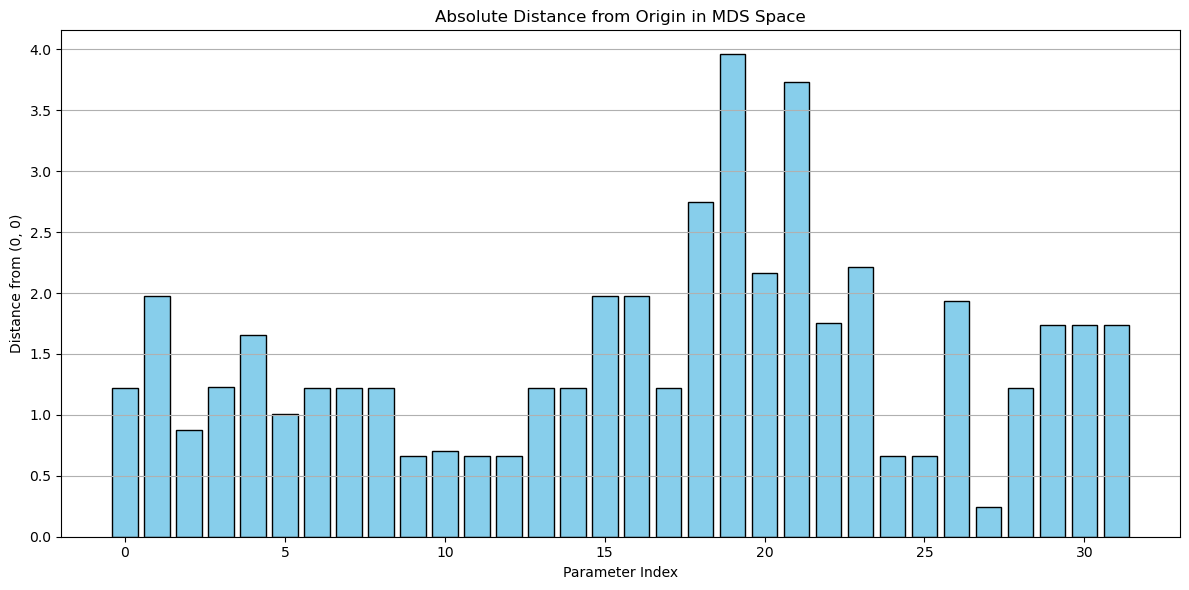

In [14]:
# Calculate absolute distance from origin for each point

distances = np.linalg.norm(param_2d, axis=1)  # Euclidean distance (always positive)

# Plot as bar chart
plt.figure(figsize=(12, 6))
plt.bar(range(len(distances)), distances, color='skyblue', edgecolor='black')
plt.title("Absolute Distance from Origin in MDS Space")
plt.xlabel("Parameter Index")
plt.ylabel("Distance from (0, 0)")
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()


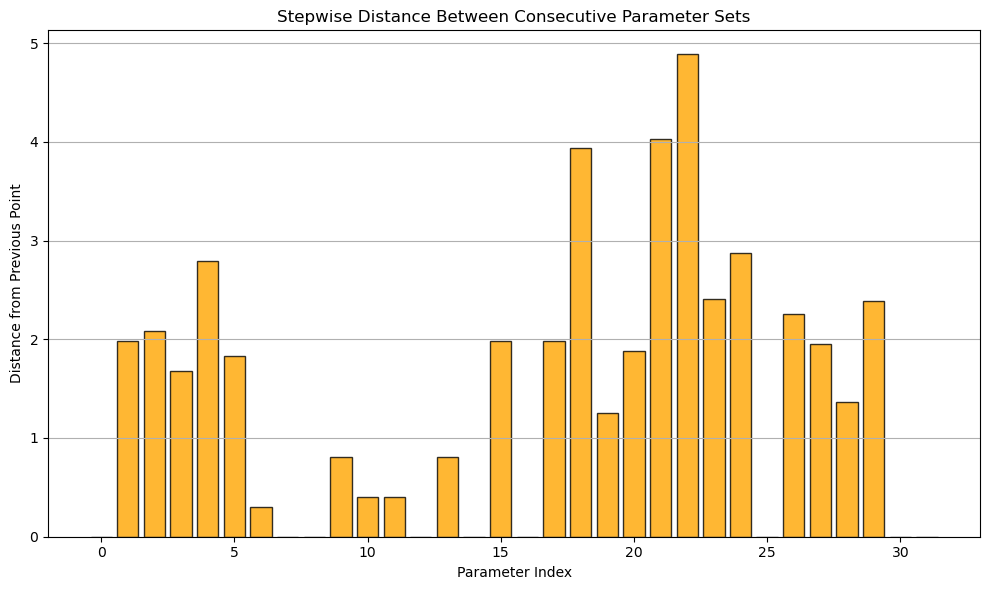

In [15]:
# Calculate distance from previous point in sequence

deltas = np.linalg.norm(np.diff(param_2d, axis=0), axis=1)

# Pad with 0 to align lengths (optional: could use NaN too)
deltas = np.insert(deltas, 0, 0)

# Plot as bar chart
plt.figure(figsize=(10, 6))
plt.bar(range(len(deltas)), deltas, color='orange', edgecolor='black', alpha=0.8)
plt.title("Stepwise Distance Between Consecutive Parameter Sets")
plt.xlabel("Parameter Index")
plt.ylabel("Distance from Previous Point")
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

